# Active-learning acquisition coverage

Plot the geometries available to each committee round on the complete HF grid. A round's training set is recorded in `acquired_before_indices`; points selected by that round therefore appear in the following round.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
from ase.io import read

# This lets the notebook import project modules when launched from notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'sampling_methods').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from sampling_methods import descriptors

# Change this if analysing a different active-learning run.
RESULT_PATH = PROJECT_ROOT / 'scripts/output/run_9/result.json'

with RESULT_PATH.open() as handle:
    result = json.load(handle)

config_path = PROJECT_ROOT / 'scripts/active-learning' / Path(result['input_file']).name
with config_path.open() as handle:
    config = json.load(handle)

hf_xyz = (config_path.parent / config['hf_xyz']).resolve()
hf_grid = read(hf_xyz, index=':')

coordinates = np.asarray([
    (
        descriptors.get_descriptor('bond_lengths', atoms)[0],
        descriptors.get_descriptor('dihedral', atoms)[0],
    )
    for atoms in hf_grid
])
cc_bond_lengths, hcch_dihedrals = coordinates.T

assert len(hf_grid) == result['hf_grid']['size']
print(f'Loaded {len(hf_grid)} grid geometries and {len(result["rounds"])} committee rounds.')

Loaded 3731 grid geometries and 3 committee rounds.


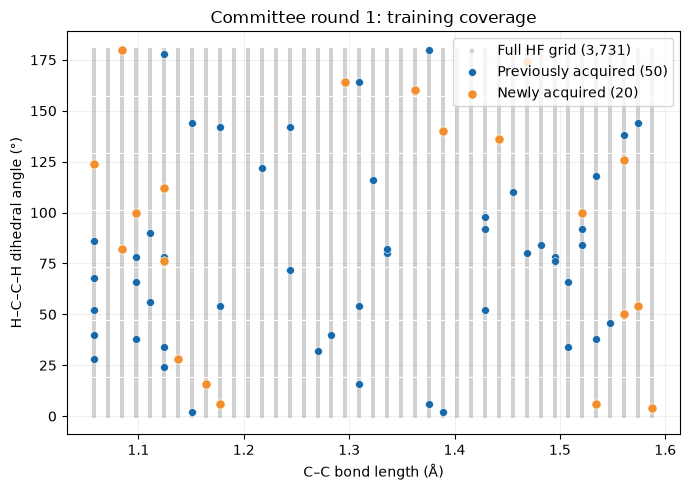

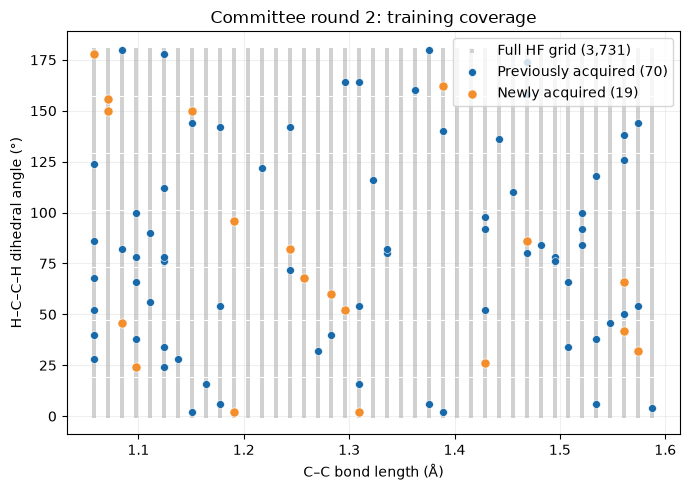

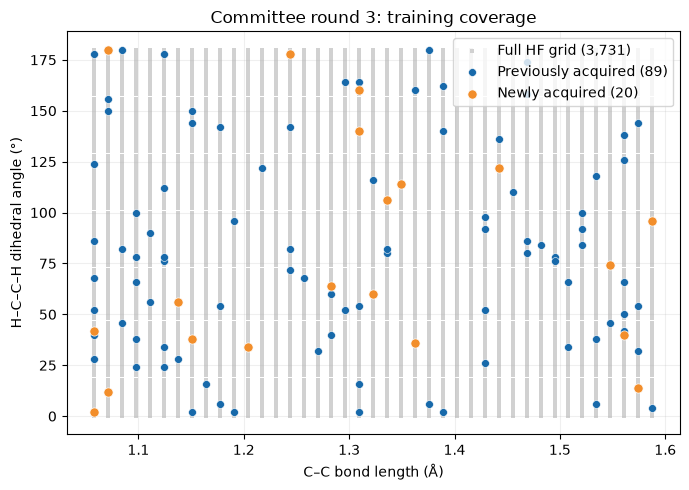

In [3]:
for round_record in result['rounds']:
    round_number = round_record['round_number'] + 1
    acquired = np.asarray(round_record['acquired_before_indices'], dtype=int)
    newly_acquired = np.asarray(
        round_record.get('selection', {}).get('acquired_indices', []), dtype=int
    )

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(
        cc_bond_lengths, hcch_dihedrals,
        s=10, color='0.82', marker='s', linewidths=0,
        label=f'Full HF grid ({len(hf_grid):,})', zorder=1,
    )
    ax.scatter(
        cc_bond_lengths[acquired], hcch_dihedrals[acquired],
        s=32, color='#1769aa', edgecolor='white', linewidth=0.4,
        label=f'Previously acquired ({len(acquired):,})', zorder=2,
    )
    ax.scatter(
        cc_bond_lengths[newly_acquired], hcch_dihedrals[newly_acquired],
        s=44, color='#f28e2b', edgecolor='white', linewidth=0.5,
        label=f'Newly acquired ({len(newly_acquired):,})', zorder=3,
    )
    ax.set(
        title=f'Committee round {round_number}: training coverage',
        xlabel='C–C bond length (Å)',
        ylabel='H–C–C–H dihedral angle (°)',
    )
    ax.legend(loc='best')
    ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()
